# 💊 Drug Classification: ML for Pharmaceutical Decision Support

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **TGA** — Drug scheduling, therapeutic goods regulation
- **PBS** — Pharmaceutical benefits, prescribing analytics
- **Dept of Health** — National Medicines Policy, antimicrobial stewardship
- **ACSQHC** — Quality Use of Medicines, clinical decision support
- **NPS MedicineWise** — Appropriate prescribing guidance

Dataset: Drug Classification — 200 samples, 5 features, 5 drug classes. Clean multiclass.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:20s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d}")
df.head()

  /kaggle/input/datasets/prathamtripathi/drug-classification/drug200.csv
Loaded: 200 x 6
   0. Age                  | int64    | uniq=   57
   1. Sex                  | object   | uniq=    2
   2. BP                   | object   | uniq=    3
   3. Cholesterol          | object   | uniq=    2
   4. Na_to_K              | float64  | uniq=  198
   5. Drug                 | object   | uniq=    5


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


## 2. Target

In [3]:
tc=None
for x in ['Drug','drug','Drug Type','target','Target','class','Class']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].dtype=='object' and 2<=df[x].nunique()<=10: tc=x;break
if tc is None: tc=df.columns[-1]
print(f"Target: '{tc}'");print(df[tc].value_counts())
le_t=LabelEncoder();df[tc]=le_t.fit_transform(df[tc].astype(str))
tl=list(le_t.classes_);nc=len(tl)
print(f"Classes: {nc} -> {tl}")

Target: 'Drug'
Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64
Classes: 5 -> ['DrugY', 'drugA', 'drugB', 'drugC', 'drugX']


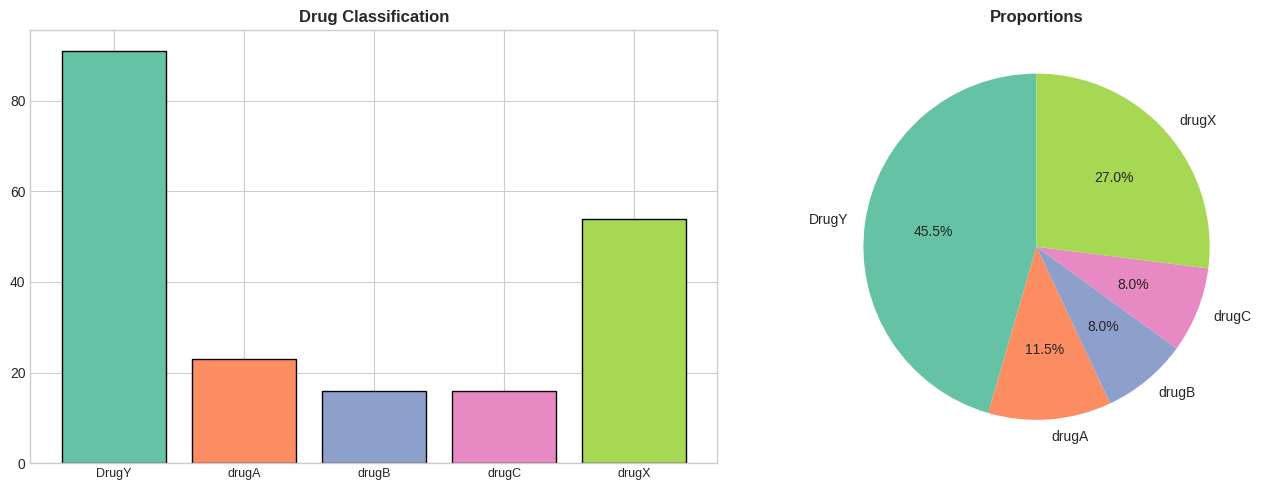

AU: PBS subsidises ~$13B in medications annually. TGA regulates ~90,000 products.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=sns.color_palette('Set2',nc)
axes[0].bar(range(len(vc)),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(len(vc)));axes[0].set_xticklabels(tl,fontsize=9)
axes[0].set_title('Drug Classification',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: PBS subsidises ~$13B in medications annually. TGA regulates ~90,000 products.")

## 3. EDA

Numeric(2): ['Age', 'Na_to_K']
Categorical(3): ['Sex', 'BP', 'Cholesterol']


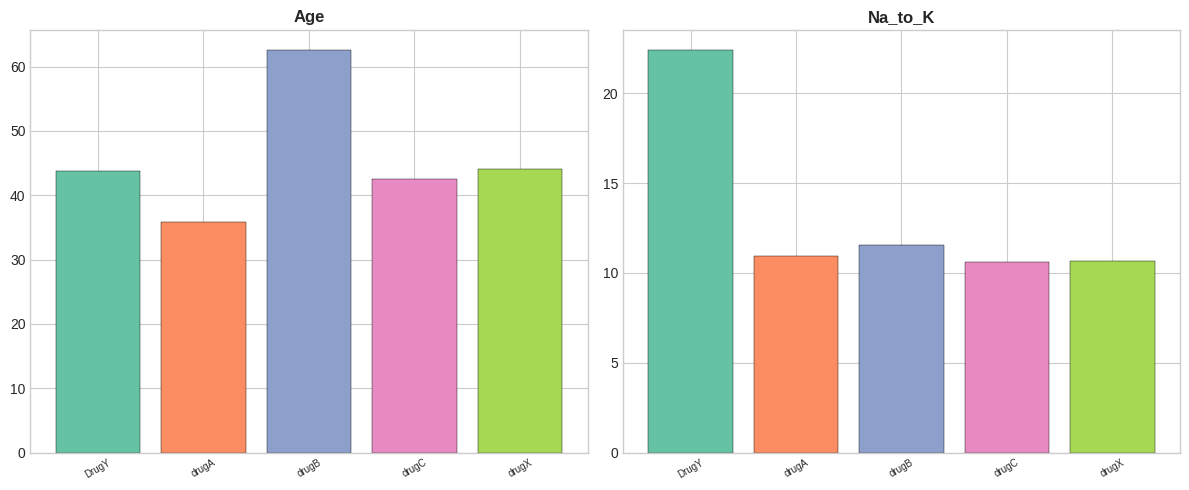

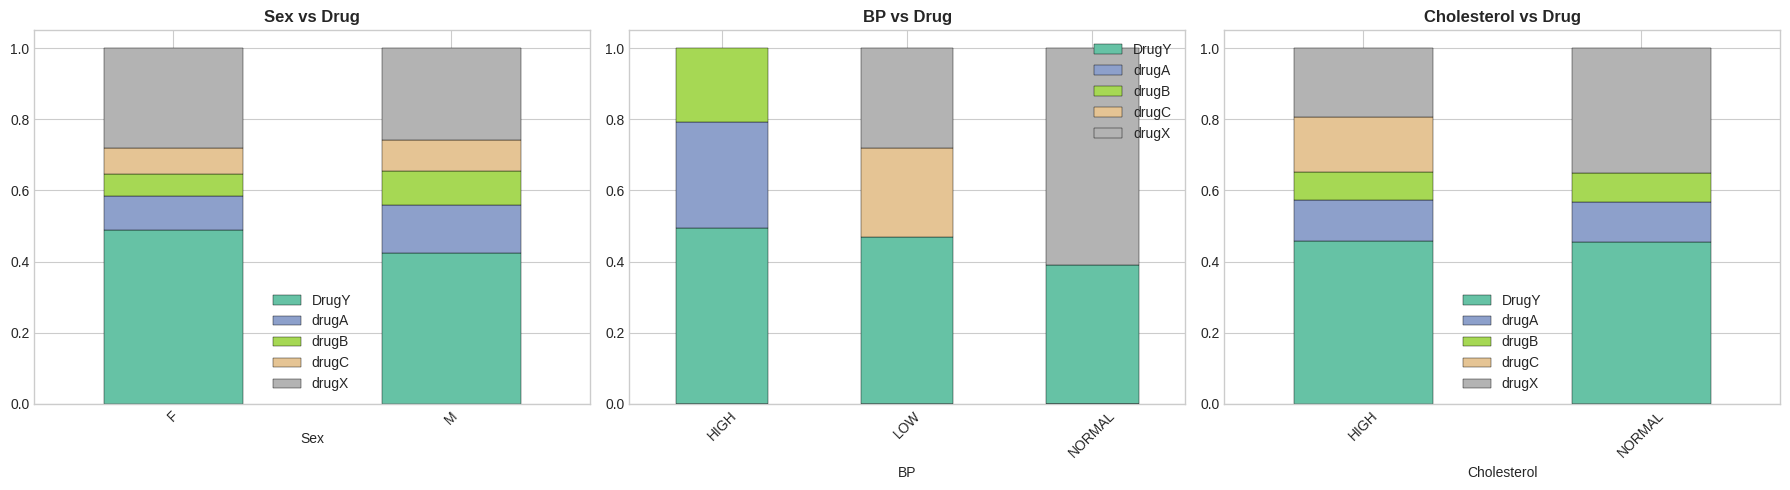

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc]
cats=[c for c in df.select_dtypes('object').columns if c!=tc and df[c].nunique()<=10]
print(f"Numeric({len(nums)}): {nums}");print(f"Categorical({len(cats)}): {cats}")
if len(nums)>0:
    fig,axes=plt.subplots(1,min(len(nums),3),figsize=(6*min(len(nums),3),5))
    if not isinstance(axes,np.ndarray): axes=[axes]
    for i,col in enumerate(nums[:3]):
        means=df.groupby(tc)[col].mean()
        axes[i].bar(range(len(means)),means.values,color=colors,edgecolor='black',linewidth=0.3)
        axes[i].set_title(col,fontweight='bold')
        axes[i].set_xticks(range(len(means)));axes[i].set_xticklabels(tl,rotation=30,fontsize=7)
    plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()
if len(cats)>0:
    fig,axes=plt.subplots(1,min(len(cats),3),figsize=(6*min(len(cats),3),5))
    if not isinstance(axes,np.ndarray): axes=[axes]
    for i,col in enumerate(cats[:3]):
        ct=pd.crosstab(df[col],df[tc],normalize='index');ct.columns=tl
        ct.plot(kind='bar',stacked=True,ax=axes[i],colormap='Set2',edgecolor='black',linewidth=0.3)
        axes[i].set_title(f'{col} vs Drug',fontweight='bold');axes[i].tick_params(axis='x',rotation=45)
    plt.tight_layout();plt.savefig('cat.png',dpi=150);plt.show()

## 4. Preprocessing

In [6]:
le_d={}
for col in df.select_dtypes('object').columns:
    if col!=tc:
        le=LabelEncoder();df[col]=le.fit_transform(df[col].fillna('_NA_').astype(str));le_d[col]=le
        print(f"  Encoded '{col}': {len(le.classes_)}")
X=df.drop(columns=[tc]);y=df[tc].values;X=X.fillna(X.median())
print(f"X: {X.shape}")

  Encoded 'Sex': 2
  Encoded 'BP': 3
  Encoded 'Cholesterol': 2
X: (200, 5)


## 5. Training

In [7]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fk=[],[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted');k=cohen_kappa_score(y[vi],yp)
        fa.append(a);ff.append(f);fk.append(k)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} K={k:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} K={np.mean(fk):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.9851 F1=0.9844 K=0.9782
  Fold2: Acc=0.9104 F1=0.9020 K=0.8720
  Fold3: Acc=0.9242 F1=0.9165 K=0.8896
  AVG: Acc=0.9399 F1=0.9343 K=0.9133 T=1.2s

RF
  Fold1: Acc=1.0000 F1=1.0000 K=1.0000
  Fold2: Acc=1.0000 F1=1.0000 K=1.0000
  Fold3: Acc=0.9697 F1=0.9692 K=0.9560
  AVG: Acc=0.9899 F1=0.9897 K=0.9853 T=0.9s

XGB
  Fold1: Acc=0.9851 F1=0.9856 K=0.9785
  Fold2: Acc=0.9701 F1=0.9697 K=0.9572
  Fold3: Acc=0.9848 F1=0.9842 K=0.9780
  AVG: Acc=0.9800 F1=0.9798 K=0.9713 T=0.3s

LGBM
  Fold1: Acc=1.0000 F1=1.0000 K=1.0000
  Fold2: Acc=0.9851 F1=0.9851 K=0.9787
  Fold3: Acc=0.9697 F1=0.9694 K=0.9564
  AVG: Acc=0.9849 F1=0.9848 K=0.9784 T=0.2s


## 6. Comparison

In [8]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'Kappa':f"{v['kappa']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','Kappa','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1  Kappa Time
    RF 0.9899 0.9897 0.9853 0.9s
  LGBM 0.9849 0.9848 0.9784 0.2s
   XGB 0.9800 0.9798 0.9713 0.3s
LogReg 0.9399 0.9343 0.9133 1.2s

Best: RF


## 7. Error Analysis

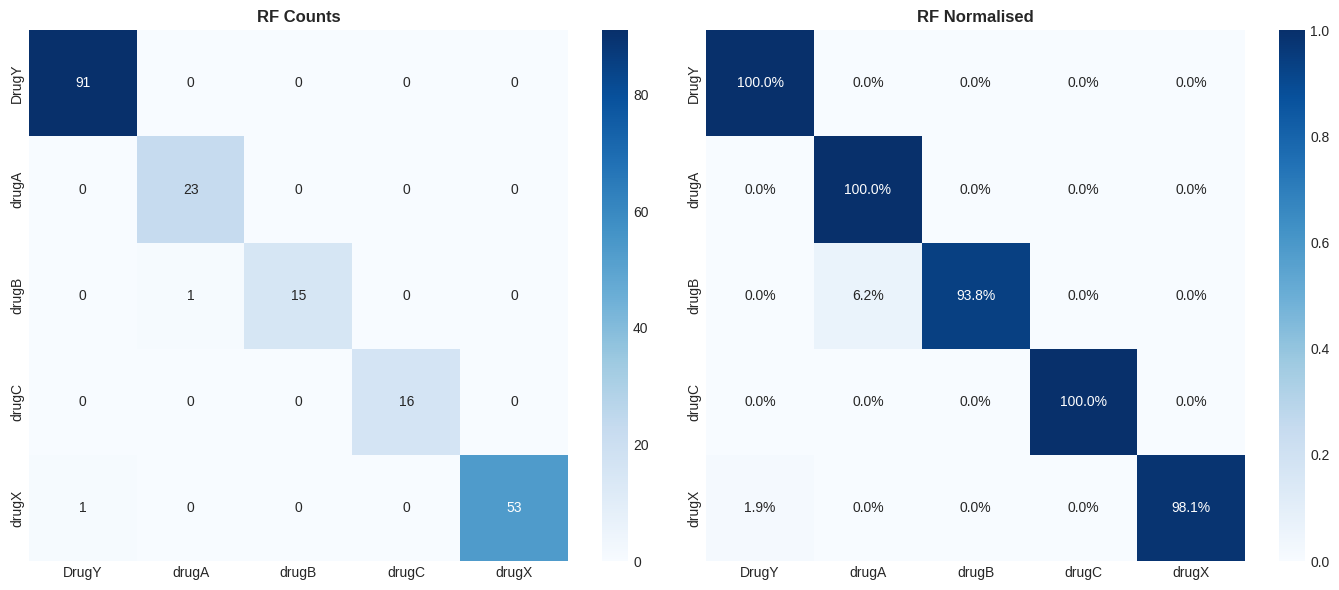

              precision    recall  f1-score   support

       DrugY       0.99      1.00      0.99        91
       drugA       0.96      1.00      0.98        23
       drugB       1.00      0.94      0.97        16
       drugC       1.00      1.00      1.00        16
       drugX       1.00      0.98      0.99        54

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



In [9]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=axes[0])
axes[0].set_title(f'{best} Counts',fontweight='bold')
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
sns.heatmap(cm_n,annot=True,fmt='.1%',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=axes[1])
axes[1].set_title(f'{best} Normalised',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

## 8. Feature Importance

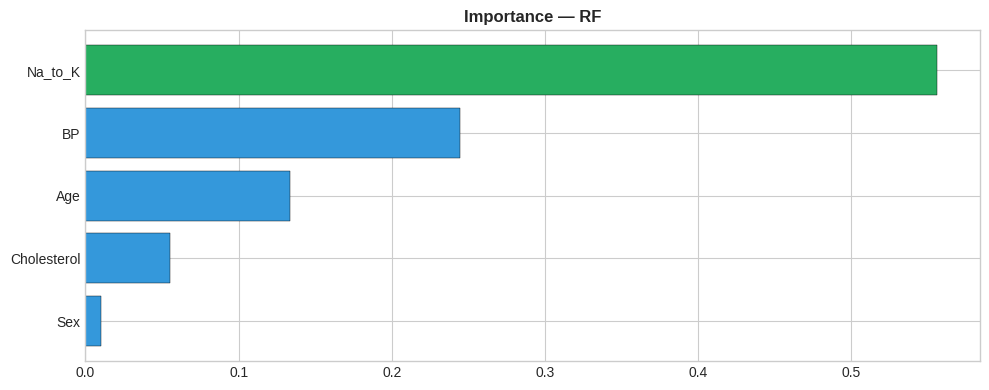

  Na_to_K              0.5561
  BP                   0.2449
  Age                  0.1334
  Cholesterol          0.0551
  Sex                  0.0105


In [10]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['f1']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(4,len(fi)*0.6)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#27ae60' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:20s} {r['Imp']:.4f}")

## 9. Deployment

In [11]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  Acc:   {br['acc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Kappa: {br['kappa']:.4f}");print(f"  Time:  {br['time']:.1f}s");print("="*60)
checks={'Acc>0.85':br['acc']>0.85,'F1>0.85':br['f1']>0.85,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  Acc:   0.9899
  F1:    0.9897
  Kappa: 0.9853
  Time:  0.9s

CHECKLIST
----------------------------------------
  [pass] Acc>0.85
  [pass] F1>0.85
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [12]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Electronic prescribing systems, pathology -> Fabric Lakehouse
2. MODEL: Real-time at prescribing decision point, clinical DSS
3. INTEGRATE: GP prescribing software, PBS Online, NPS MedicineWise
4. GOVERN: TGA compliance, RACGP prescribing guidelines, patient consent
5. MONITOR: Validate vs specialist prescribing, retrain with new guidelines
   Model supports Quality Use of Medicines — never replaces clinical judgment
""")


PRODUCTION ARCHITECTURE
1. DATA: Electronic prescribing systems, pathology -> Fabric Lakehouse
2. MODEL: Real-time at prescribing decision point, clinical DSS
3. INTEGRATE: GP prescribing software, PBS Online, NPS MedicineWise
4. GOVERN: TGA compliance, RACGP prescribing guidelines, patient consent
5. MONITOR: Validate vs specialist prescribing, retrain with new guidelines
   Model supports Quality Use of Medicines — never replaces clinical judgment

